## 0. Dataset Preparation

In [ ]:
!pip install transformers
!pip install -q transformers datasets
!pip install transformers[torch]

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import torch
import torch.nn as nn
import numpy as np
import ast
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification, Trainer, TrainingArguments
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import BertTokenizerFast, BertForSequenceClassification
from transformers import EvalPrediction
import os
from datasets import load_dataset

In [ ]:
if torch.cuda.is_available():
    device = torch.cuda.get_device_name(0)
    print('GPU device:', device)
else:
    print('No GPU available.')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

GPU device: Tesla V100-SXM2-16GB


In [ ]:
drive.mount('/content/gdrive')
df = pd.read_csv('/content/gdrive/My Drive/MSc Project/fabsa.csv')


Mounted at /content/gdrive


Convert the representation of 'labels' and split the data

In [ ]:
# Convert the string representation of lists in 'labels' column to actual list
df['labels'] = df['labels'].apply(ast.literal_eval)

# Now you can generate the unique list of labels as before
labels = list(set([label for sublist in df['labels'].tolist() for label in sublist]))
id2label = {idx: label for idx, label in enumerate(labels)}
label2id = {label: idx for idx, label in enumerate(labels)}

Load dataset

In [ ]:
# Load data set and convert the string representation of lists in 'labels' column to actual list for each train and val data set
train_subset01 = pd.read_csv("/content/gdrive/My Drive/MSc Project/train_subset.csv", converters={'labels': ast.literal_eval})
val_df = pd.read_csv("/content/gdrive/My Drive/MSc Project/val_df.csv", converters={'labels': ast.literal_eval})

# Convert the pandas DataFrame to a Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_subset01)
val_dataset = Dataset.from_pandas(val_df)

all_datasets = {}

dataset_key = "original_subset01"

# Combine them into a DatasetDict
dataset = DatasetDict({
        'train': train_dataset,
        'validation': val_dataset
    })

all_datasets[dataset_key] = dataset

In [ ]:
# Load data set and convert the string representation of lists in 'labels' column to actual list for each train and val data set
train_subset05 = pd.read_csv("/content/gdrive/My Drive/MSc Project/train_subset5.csv", converters={'labels': ast.literal_eval})
val_df = pd.read_csv("/content/gdrive/My Drive/MSc Project/val_df.csv", converters={'labels': ast.literal_eval})

# Convert the pandas DataFrame to a Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_subset05)
val_dataset = Dataset.from_pandas(val_df)

dataset_key = "original_subset05"

# Combine them into a DatasetDict
dataset = DatasetDict({
        'train': train_dataset,
        'validation': val_dataset
    })

all_datasets[dataset_key] = dataset

In [ ]:
# Load data set and convert the string representation of lists in 'labels' column to actual list for each train and val data set
train_subset10 = pd.read_csv("/content/gdrive/My Drive/MSc Project/train_subset10.csv", converters={'labels': ast.literal_eval})
val_df = pd.read_csv("/content/gdrive/My Drive/MSc Project/val_df.csv", converters={'labels': ast.literal_eval})

# Convert the pandas DataFrame to a Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_subset10)
val_dataset = Dataset.from_pandas(val_df)

dataset_key = "original_subset10"

# Combine them into a DatasetDict
dataset = DatasetDict({
        'train': train_dataset,
        'validation': val_dataset
    })

all_datasets[dataset_key] = dataset

In [ ]:
# Load data set and convert the string representation of lists in 'labels' column to actual list for each train and val data set
train_subset20 = pd.read_csv("/content/gdrive/My Drive/MSc Project/train_subset20.csv", converters={'labels': ast.literal_eval})
val_df = pd.read_csv("/content/gdrive/My Drive/MSc Project/val_df.csv", converters={'labels': ast.literal_eval})

# Convert the pandas DataFrame to a Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_subset20)
val_dataset = Dataset.from_pandas(val_df)

dataset_key = "original_subset20"

# Combine them into a DatasetDict
dataset = DatasetDict({
        'train': train_dataset,
        'validation': val_dataset
    })

all_datasets[dataset_key] = dataset

In [ ]:
# Load data set and convert the string representation of lists in 'labels' column to actual list for each train and val data set
train_subset30 = pd.read_csv("/content/gdrive/My Drive/MSc Project/train_subset30.csv", converters={'labels': ast.literal_eval})
val_df = pd.read_csv("/content/gdrive/My Drive/MSc Project/val_df.csv", converters={'labels': ast.literal_eval})

# Convert the pandas DataFrame to a Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_subset30)
val_dataset = Dataset.from_pandas(val_df)

dataset_key = "original_subset30"

# Combine them into a DatasetDict
dataset = DatasetDict({
        'train': train_dataset,
        'validation': val_dataset
    })

all_datasets[dataset_key] = dataset

Size of each subset

In [ ]:
print(len(train_subset01), len(train_subset05), len(train_subset10), len(train_subset20), len(train_subset30))

88 380 750 1517 2247


## XLnet


*   XLnet-base-cased
*   XLnet-large-cased



XLnet-base-cased

In [ ]:
# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained("xlnet-base-cased")

# Preprocessing function
def preprocess_data(examples):
    text = examples["text"]
    encoding = tokenizer(text, padding="max_length", truncation=True, max_length=128)

    labels_batch = examples["labels"]
    labels_matrix = np.zeros((len(text), len(labels)))

    for i, label_list in enumerate(labels_batch):
        for label in label_list:
            idx = label2id[label]
            labels_matrix[i, idx] = 1

    encoding["labels"] = labels_matrix.tolist()

    return encoding

# Define metrics
def multi_label_metrics(predictions, labels, threshold=0.5):
    sigmoid = torch.nn.Sigmoid()
    probs = sigmoid(torch.Tensor(predictions))
    y_pred = np.zeros(probs.shape)
    y_pred[np.where(probs >= threshold)] = 1
    y_true = labels
    f1_micro_average = f1_score(y_true=y_true, y_pred=y_pred, average='micro')
    roc_auc = roc_auc_score(y_true, y_pred, average='micro')
    accuracy = accuracy_score(y_true, y_pred)
    metrics = {'f1': f1_micro_average,
               'roc_auc': roc_auc,
               'accuracy': accuracy}
    return metrics

def compute_metrics(p: EvalPrediction):
    preds = p.predictions[0] if isinstance(p.predictions, tuple) else p.predictions
    result = multi_label_metrics(predictions=preds, labels=p.label_ids)
    return result

# Function to train and evaluate the model for a given dataset
def train_and_evaluate_model(dataset, dataset_key, lr, batch_size):
    print(f"Training with {dataset_key} data, lr {lr}, batch_size {batch_size}...")

    # Apply preprocessing
    encoded_dataset = dataset.map(preprocess_data, batched=True, remove_columns=['text', 'labels'])
    # Set format to PyTorch tensors
    encoded_dataset.set_format("torch")
    # Define the model
    model = AutoModelForSequenceClassification.from_pretrained("xlnet-base-cased",
                                                               problem_type="multi_label_classification",
                                                               num_labels=len(labels),
                                                               id2label=id2label,
                                                               label2id=label2id)

    # Training arguments
    training_args = TrainingArguments(
        output_dir=f"xlnet-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=10,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
    )

    # Define the trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=encoded_dataset["train"],
        eval_dataset=encoded_dataset["validation"],
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )

    # Start training
    trainer.train()

    # Evaluate the model
    result = trainer.evaluate()
    print(f"Results with {dataset_key}: {result}")

    return result

##1%

In [ ]:
# Create a DataFrame to store the results
hyperparam_subset01_xlnetbase = pd.DataFrame(columns=['learning_rate', 'train_batch_size', 'f1_score'])

In [ ]:
# Create a DataFrame to store the results
hyperparam_subset01_xlnetbase = pd.read_csv('/content/gdrive/My Drive/MSc Project/hyperparam_subset01_xlnetbase.csv')

In [ ]:
# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [4e-5, 6e-5],
    'train_batch_size': [8, 16],
}

# Select only the "original" dataset
dataset_key = "original_subset01"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        hyperparam_subset01_xlnetbase = hyperparam_subset01_xlnetbase.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)

        # Save the DataFrame to the CSV file
        hyperparam_subset01_xlnetbase.to_csv('/content/gdrive/My Drive/MSc Project/hyperparam_subset01_xlnetbase.csv', index=False)

        # Remove the folder after processing
        folder_path = f"/content/xlnet-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}"
        !rm -r $folder_path


Training with original_subset01 data, lr 4e-05, batch_size 8...


Map:   0%|          | 0/88 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-base-cased and are newly initialized: ['sequence_summary.summary.bias', 'logits_proj.weight', 'logits_proj.bias', 'sequence_summary.summary.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.337371,0.011569,0.502639,0.001261
2,No log,0.236211,0.000000,0.500000,0.000000
3,No log,0.207057,0.000000,0.500000,0.000000
4,No log,0.192609,0.000000,0.500000,0.000000
5,No log,0.184026,0.000000,0.500000,0.000000
6,No log,0.179210,0.000000,0.500000,0.000000
7,No log,0.175702,0.000000,0.500000,0.000000
8,No log,0.173854,0.000000,0.500000,0.000000
9,No log,0.172727,0.000000,0.500000,0.000000
10,No log,0.172385,0.000000,0.500000,0.000000


...

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-base-cased and are newly initialized: ['sequence_summary.summary.bias', 'logits_proj.weight', 'logits_proj.bias', 'sequence_summary.summary.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.343375,0.007781,0.501838,0.002206
2,No log,0.251783,0.000000,0.500000,0.000000
3,No log,0.221027,0.000000,0.500000,0.000000
4,No log,0.202115,0.000000,0.500000,0.000000
5,No log,0.192150,0.000000,0.500000,0.000000
6,No log,0.186037,0.000000,0.500000,0.000000
7,No log,0.182094,0.000000,0.500000,0.000000
8,No log,0.179613,0.000000,0.500000,0.000000
9,No log,0.178228,0.000000,0.500000,0.000000
10,No log,0.177765,0.000000,0.500000,0.000000


Results with original_subset01: {'eval_loss': 0.3433745801448822, 'eval_f1': 0.007780725022104333, 'eval_roc_auc': 0.5018378991599712, 'eval_accuracy': 0.002206114087614245, 'eval_runtime': 11.016, 'eval_samples_per_second': 288.035, 'eval_steps_per_second': 18.065, 'epoch': 10.0}


<ipython-input-26-f3971bc131d8>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_subset01_xlnetbase = hyperparam_subset01_xlnetbase.append({


In [ ]:
# Print out the best hyperparameters
best_hyperparams = hyperparam_subset01_xlnetbase.loc[hyperparam_subset01_xlnetbase['f1_score'].idxmax()]
print(f"Best hyperparameters for xlnet-base model:\n{best_hyperparams}")

Best hyperparameters for xlnet-base model:
learning_rate        0.000010
train_batch_size    16.000000
f1_score             0.127189
Name: 5, dtype: float64


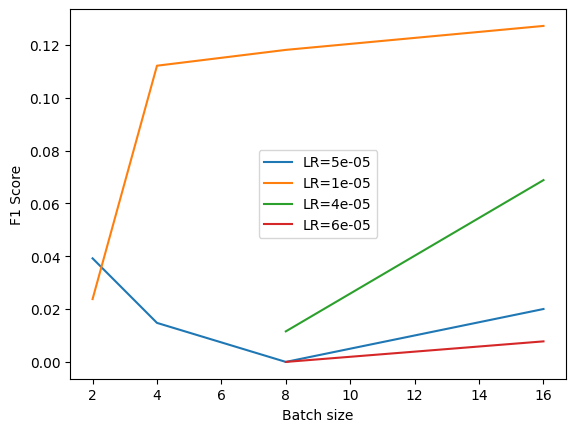

In [ ]:
# Extract unique learning rates from the DataFrame
learning_rates = hyperparam_subset01_xlnetbase['learning_rate'].unique()

# Plot the results
for lr in learning_rates:
    temp_df = hyperparam_subset01_xlnetbase[hyperparam_subset01_xlnetbase['learning_rate'] == lr]

    # Sort temp_df by 'train_batch_size' before plotting
    temp_df = temp_df.sort_values(by='train_batch_size')

    plt.plot(temp_df['train_batch_size'], temp_df['f1_score'], label=f'LR={lr}')

plt.xlabel('Batch size')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

In [ ]:
hyperparam_subset01_xlnetbase

,learning_rate,train_batch_size,f1_score
0,0.00005,4.0,0.014776
1,0.00005,8.0,0.000000
2,0.00005,16.0,0.020031
3,0.00001,4.0,0.112129
4,0.00001,8.0,0.118120
5,0.00001,16.0,0.127189
6,0.00005,2.0,0.039209
7,0.00001,2.0,0.023786
8,0.00004,8.0,0.011569
9,0.00004,16.0,0.068820


##5%

In [ ]:
# Create a DataFrame to store the results
hyperparam_subset05_xlnetbase = pd.DataFrame(columns=['learning_rate', 'train_batch_size', 'f1_score'])

In [ ]:
# Create a DataFrame to store the results
hyperparam_subset05_xlnetbase = pd.read_csv('/content/gdrive/My Drive/MSc Project/hyperparam_subset05_xlnetbase.csv')

In [ ]:
# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [6e-5, 7e-5],
    'train_batch_size': [4, 8, 16],
}

# Select only the "original" dataset
dataset_key = "original_subset05"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        hyperparam_subset05_xlnetbase = hyperparam_subset05_xlnetbase.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)

        # Save the DataFrame to the CSV file
        hyperparam_subset05_xlnetbase.to_csv('/content/gdrive/My Drive/MSc Project/hyperparam_subset05_xlnetbase.csv', index=False)

        # Remove the folder after processing
        folder_path = f"/content/xlnet-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}"
        !rm -r $folder_path


Training with original_subset05 data, lr 6e-05, batch_size 4...


Map:   0%|          | 0/380 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-base-cased and are newly initialized: ['sequence_summary.summary.bias', 'logits_proj.weight', 'logits_proj.bias', 'sequence_summary.summary.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.158072,0.000000,0.500000,0.000000
2,No log,0.150784,0.000000,0.500000,0.000000
3,No log,0.142629,0.000000,0.500000,0.000000
4,No log,0.140687,0.048756,0.512216,0.008194
5,No log,0.135885,0.010915,0.502567,0.001261
6,0.166000,0.132548,0.126092,0.534201,0.039710
7,0.166000,0.130193,0.162348,0.545090,0.029940
8,0.166000,0.128383,0.272007,0.585453,0.075953
9,0.166000,0.127338,0.278577,0.588130,0.079420
10,0.166000,0.126447,0.338358,0.613231,0.143397


...

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-base-cased and are newly initialized: ['sequence_summary.summary.bias', 'logits_proj.weight', 'logits_proj.bias', 'sequence_summary.summary.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.187886,0.000000,0.500000,0.000000
2,No log,0.161389,0.000000,0.500000,0.000000
3,No log,0.156794,0.000000,0.500000,0.000000
4,No log,0.154067,0.000000,0.500000,0.000000
5,No log,0.150636,0.000000,0.500000,0.000000
6,No log,0.148736,0.000000,0.500000,0.000000
7,No log,0.146512,0.000000,0.500000,0.000000
8,No log,0.142261,0.015789,0.503788,0.000315
9,No log,0.139641,0.079074,0.520396,0.016388
10,No log,0.138951,0.055254,0.513935,0.008824


Results with original_subset05: {'eval_loss': 0.13964064419269562, 'eval_f1': 0.07907361455748552, 'eval_roc_auc': 0.5203958228495914, 'eval_accuracy': 0.016388276079420106, 'eval_runtime': 11.0706, 'eval_samples_per_second': 286.615, 'eval_steps_per_second': 17.976, 'epoch': 10.0}


<ipython-input-41-bcd5336d6124>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_subset05_xlnetbase = hyperparam_subset05_xlnetbase.append({


In [ ]:
# Print out the best hyperparameters
best_hyperparams = hyperparam_subset05_xlnetbase.loc[hyperparam_subset05_xlnetbase['f1_score'].idxmax()]
print(f"Best hyperparameters for xlnet-base model:\n{best_hyperparams}")

Best hyperparameters for xlnet-base model:
learning_rate       0.00006
train_batch_size    8.00000
f1_score            0.42370
Name: 7, dtype: float64


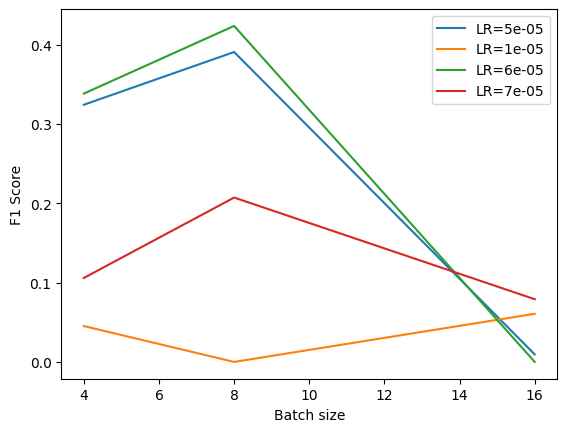

In [ ]:
# Extract unique learning rates from the DataFrame
learning_rates = hyperparam_subset05_xlnetbase['learning_rate'].unique()

# Plot the results
for lr in learning_rates:
    temp_df = hyperparam_subset05_xlnetbase[hyperparam_subset05_xlnetbase['learning_rate'] == lr]

    # Sort temp_df by 'train_batch_size' before plotting
    temp_df = temp_df.sort_values(by='train_batch_size')

    plt.plot(temp_df['train_batch_size'], temp_df['f1_score'], label=f'LR={lr}')

plt.xlabel('Batch size')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

In [ ]:
hyperparam_subset05_xlnetbase

,learning_rate,train_batch_size,f1_score
0,0.00005,4.0,0.324297
1,0.00005,8.0,0.390799
2,0.00005,16.0,0.009534
3,0.00001,4.0,0.045227
4,0.00001,8.0,0.000000
5,0.00001,16.0,0.060672
6,0.00006,4.0,0.338358
7,0.00006,8.0,0.423700
8,0.00006,16.0,0.000000
9,0.00007,4.0,0.105890


##10%

In [ ]:
# Create a DataFrame to store the results
hyperparam_subset10_xlnetbase = pd.DataFrame(columns=['learning_rate', 'train_batch_size', 'f1_score'])

In [ ]:
# Create a DataFrame to store the results
hyperparam_subset10_xlnetbase = pd.read_csv('/content/gdrive/My Drive/MSc Project/hyperparam_subset10_xlnetbase.csv')

In [ ]:
# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [4e-5, 5e-5, 6e-5, 7e-5],
    'train_batch_size': [2],
}

# Select only the "original" dataset
dataset_key = "original_subset10"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        hyperparam_subset10_xlnetbase = hyperparam_subset10_xlnetbase.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)

        # Save the DataFrame to the CSV file
        hyperparam_subset10_xlnetbase.to_csv('/content/gdrive/My Drive/MSc Project/hyperparam_subset10_xlnetbase.csv', index=False)

        # Remove the folder after processing
        folder_path = f"/content/xlnet-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}"
        !rm -r $folder_path


Training with original_subset10 data, lr 4e-05, batch_size 2...


Map:   0%|          | 0/750 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-base-cased and are newly initialized: ['sequence_summary.summary.bias', 'logits_proj.weight', 'logits_proj.bias', 'sequence_summary.summary.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.149120,0.000000,0.500000,0.000000
2,0.177700,0.132500,0.000000,0.500000,0.000000
3,0.136400,0.123733,0.362044,0.627532,0.172707
4,0.122400,0.114456,0.450153,0.671682,0.196974
5,0.122400,0.111988,0.476827,0.679842,0.234163
6,0.103500,0.106709,0.491671,0.686453,0.253703
7,0.087600,0.098831,0.576619,0.733293,0.311377
8,0.074500,0.095369,0.599049,0.748140,0.325875
9,0.074500,0.093800,0.624222,0.763730,0.353924
10,0.063800,0.093116,0.629756,0.767604,0.358336


...

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-base-cased and are newly initialized: ['sequence_summary.summary.bias', 'logits_proj.weight', 'logits_proj.bias', 'sequence_summary.summary.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.154725,0.000000,0.500000,0.000000
2,0.173900,0.148799,0.000000,0.500000,0.000000
3,0.155700,0.153112,0.000000,0.500000,0.000000
4,0.156400,0.151940,0.000000,0.500000,0.000000
5,0.156400,0.153596,0.000000,0.500000,0.000000
6,0.154600,0.152975,0.000000,0.500000,0.000000
7,0.155900,0.152647,0.000000,0.500000,0.000000
8,0.155700,0.152595,0.000000,0.500000,0.000000
9,0.155700,0.152594,0.000000,0.500000,0.000000
10,0.154900,0.152591,0.000000,0.500000,0.000000


Results with original_subset10: {'eval_loss': 0.15472526848316193, 'eval_f1': 0.0, 'eval_roc_auc': 0.5, 'eval_accuracy': 0.0, 'eval_runtime': 36.5415, 'eval_samples_per_second': 86.833, 'eval_steps_per_second': 43.43, 'epoch': 10.0}


<ipython-input-61-45d7bd595dde>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_subset10_xlnetbase = hyperparam_subset10_xlnetbase.append({


In [ ]:
# Print out the best hyperparameters
best_hyperparams = hyperparam_subset10_xlnetbase.loc[hyperparam_subset10_xlnetbase['f1_score'].idxmax()]
print(f"Best hyperparameters for xlnet-base model:\n{best_hyperparams}")

Best hyperparameters for xlnet-base model:
learning_rate       0.000040
train_batch_size    2.000000
f1_score            0.629756
Name: 11, dtype: float64


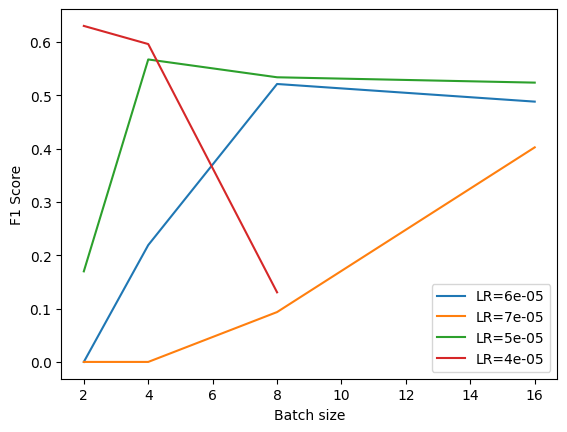

In [ ]:
# Extract unique learning rates from the DataFrame
learning_rates = hyperparam_subset10_xlnetbase['learning_rate'].unique()

# Plot the results
for lr in learning_rates:
    temp_df = hyperparam_subset10_xlnetbase[hyperparam_subset10_xlnetbase['learning_rate'] == lr]

    # Sort temp_df by 'train_batch_size' before plotting
    temp_df = temp_df.sort_values(by='train_batch_size')

    plt.plot(temp_df['train_batch_size'], temp_df['f1_score'], label=f'LR={lr}')

plt.xlabel('Batch size')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

In [ ]:
hyperparam_subset10_xlnetbase

,learning_rate,train_batch_size,f1_score
0,0.00006,4.0,0.219004
1,0.00006,8.0,0.520922
2,0.00006,16.0,0.487862
3,0.00007,4.0,0.000000
4,0.00007,8.0,0.093449
5,0.00007,16.0,0.402166
6,0.00005,4.0,0.566910
7,0.00005,8.0,0.533502
8,0.00005,16.0,0.523481
9,0.00004,4.0,0.595758


##20%

In [ ]:
# Create a DataFrame to store the results
hyperparam_subset20_xlnetbase = pd.DataFrame(columns=['learning_rate', 'train_batch_size', 'f1_score'])

In [ ]:
# Create a DataFrame to store the results
hyperparam_subset20_xlnetbase = pd.read_csv('/content/gdrive/My Drive/MSc Project/hyperparam_subset20_xlnetbase.csv')

In [ ]:
# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [1e-5],
    'train_batch_size': [2,8,16],
}

# Select only the "original" dataset
dataset_key = "original_subset20"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        hyperparam_subset20_xlnetbase = hyperparam_subset20_xlnetbase.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)

        # Save the DataFrame to the CSV file
        hyperparam_subset20_xlnetbase.to_csv('/content/gdrive/My Drive/MSc Project/hyperparam_subset20_xlnetbase.csv', index=False)

        # Remove the folder after processing
        folder_path = f"/content/xlnet-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}"
        !rm -r $folder_path


Training with original_subset20 data, lr 1e-05, batch_size 2...


Map:   0%|          | 0/1517 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-base-cased and are newly initialized: ['sequence_summary.summary.bias', 'logits_proj.weight', 'logits_proj.bias', 'sequence_summary.summary.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,0.227300,0.141044,0.004626,0.501155,0.000000
2,0.126200,0.113402,0.501228,0.679749,0.238575
3,0.106400,0.101279,0.569557,0.724925,0.283328
4,0.087600,0.094050,0.612214,0.749235,0.338166
5,0.077500,0.087042,0.650059,0.768919,0.384494
6,0.068100,0.084841,0.662534,0.777723,0.400252
7,0.063400,0.084038,0.666115,0.783077,0.406870
8,0.055100,0.082320,0.677413,0.790395,0.420107
9,0.052500,0.082343,0.687481,0.802870,0.431138
10,0.049900,0.081761,0.683364,0.798657,0.430823


...

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-base-cased and are newly initialized: ['sequence_summary.summary.bias', 'logits_proj.weight', 'logits_proj.bias', 'sequence_summary.summary.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.198993,0.000000,0.500000,0.000000
2,No log,0.173137,0.000000,0.500000,0.000000
3,No log,0.163542,0.000000,0.500000,0.000000
4,No log,0.153814,0.000000,0.500000,0.000000
5,No log,0.143969,0.091032,0.523824,0.017964
6,0.197500,0.138554,0.136014,0.536666,0.024267
7,0.197500,0.134325,0.252231,0.574390,0.055783
8,0.197500,0.130939,0.305119,0.593688,0.070911
9,0.197500,0.128739,0.334629,0.605674,0.083202
10,0.197500,0.128281,0.353198,0.613513,0.092342


Results with original_subset20: {'eval_loss': 0.12828122079372406, 'eval_f1': 0.3531978726305742, 'eval_roc_auc': 0.6135127012224025, 'eval_accuracy': 0.09234163252442483, 'eval_runtime': 11.0121, 'eval_samples_per_second': 288.137, 'eval_steps_per_second': 18.071, 'epoch': 10.0}


<ipython-input-71-e336c35723d6>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_subset20_xlnetbase = hyperparam_subset20_xlnetbase.append({


In [ ]:
# Print out the best hyperparameters
best_hyperparams = hyperparam_subset20_xlnetbase.loc[hyperparam_subset20_xlnetbase['f1_score'].idxmax()]
print(f"Best hyperparameters for xlnet-base model:\n{best_hyperparams}")

Best hyperparameters for xlnet-base model:
learning_rate       0.000010
train_batch_size    2.000000
f1_score            0.687481
Name: 9, dtype: float64


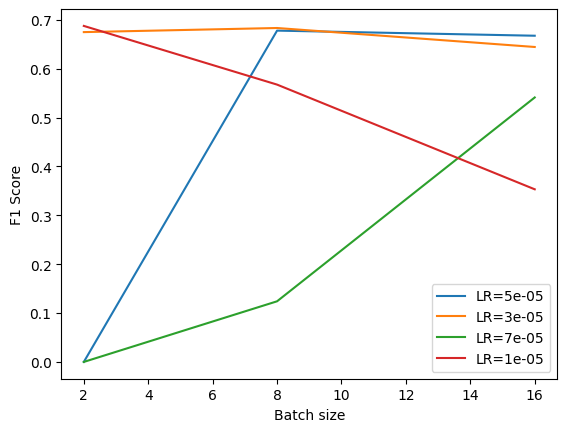

In [ ]:
# Extract unique learning rates from the DataFrame
learning_rates = hyperparam_subset20_xlnetbase['learning_rate'].unique()

# Plot the results
for lr in learning_rates:
    temp_df = hyperparam_subset20_xlnetbase[hyperparam_subset20_xlnetbase['learning_rate'] == lr]

    # Sort temp_df by 'train_batch_size' before plotting
    temp_df = temp_df.sort_values(by='train_batch_size')

    plt.plot(temp_df['train_batch_size'], temp_df['f1_score'], label=f'LR={lr}')

plt.xlabel('Batch size')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

In [ ]:
hyperparam_subset20_xlnetbase

,learning_rate,train_batch_size,f1_score
0,0.00005,2.0,0.000000
1,0.00005,8.0,0.677871
2,0.00005,16.0,0.667418
3,0.00003,2.0,0.674814
4,0.00003,8.0,0.683226
5,0.00003,16.0,0.644395
6,0.00007,2.0,0.000000
7,0.00007,8.0,0.124046
8,0.00007,16.0,0.541110
9,0.00001,2.0,0.687481


##30%

In [ ]:
# Create a DataFrame to store the results
hyperparam_subset30_xlnetbase = pd.DataFrame(columns=['learning_rate', 'train_batch_size', 'f1_score'])

In [ ]:
# Create a DataFrame to store the results
hyperparam_subset30_xlnetbase = pd.read_csv('/content/gdrive/My Drive/MSc Project/hyperparam_subset30_xlnetbase.csv')

In [ ]:
# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [2e-5, 1e-5],
    'train_batch_size': [2,8,16],
}

# Select only the "original" dataset
dataset_key = "original_subset30"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        hyperparam_subset30_xlnetbase = hyperparam_subset30_xlnetbase.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)

        # Save the DataFrame to the CSV file
        hyperparam_subset30_xlnetbase.to_csv('/content/gdrive/My Drive/MSc Project/hyperparam_subset30_xlnetbase.csv', index=False)

        # Remove the folder after processing
        folder_path = f"/content/xlnet-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}"
        !rm -r $folder_path

Training with original_subset30 data, lr 2e-05, batch_size 2...


Map:   0%|          | 0/2247 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-base-cased and are newly initialized: ['sequence_summary.summary.bias', 'logits_proj.weight', 'logits_proj.bias', 'sequence_summary.summary.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,0.127600,0.115488,0.500059,0.686069,0.219351
2,0.101800,0.095893,0.597771,0.742325,0.327450
3,0.081300,0.082291,0.675819,0.792213,0.417271
4,0.064800,0.077994,0.704331,0.821168,0.460763
5,0.049000,0.074484,0.724167,0.835208,0.464860
6,0.038400,0.074331,0.721974,0.832953,0.473999
7,0.032300,0.074121,0.734818,0.848832,0.476521
8,0.027300,0.073851,0.739033,0.849198,0.484084
9,0.023900,0.072954,0.741806,0.849057,0.492279
10,0.022100,0.073184,0.742185,0.849489,0.488182


...

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-base-cased and are newly initialized: ['sequence_summary.summary.bias', 'logits_proj.weight', 'logits_proj.bias', 'sequence_summary.summary.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.181158,0.000000,0.500000,0.000000
2,No log,0.161593,0.000000,0.500000,0.000000
3,No log,0.144762,0.004976,0.501216,0.000000
4,0.197200,0.135152,0.218377,0.563602,0.038765
5,0.197200,0.125157,0.372458,0.622580,0.104003
6,0.197200,0.118543,0.488473,0.678246,0.193508
7,0.197200,0.112947,0.544030,0.707221,0.258115
8,0.123400,0.109657,0.553030,0.711651,0.268200
9,0.123400,0.107460,0.563105,0.715156,0.273558
10,0.123400,0.106806,0.563371,0.715330,0.275134


Results with original_subset30: {'eval_loss': 0.10680589824914932, 'eval_f1': 0.5633705537009325, 'eval_roc_auc': 0.7153299278944963, 'eval_accuracy': 0.27513394264103375, 'eval_runtime': 10.9859, 'eval_samples_per_second': 288.824, 'eval_steps_per_second': 18.114, 'epoch': 10.0}


<ipython-input-81-48f6ff547b2d>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_subset30_xlnetbase = hyperparam_subset30_xlnetbase.append({


In [ ]:
# Print out the best hyperparameters
best_hyperparams = hyperparam_subset30_xlnetbase.loc[hyperparam_subset30_xlnetbase['f1_score'].idxmax()]
print(f"Best hyperparameters for xlnet-base model:\n{best_hyperparams}")

Best hyperparameters for xlnet-base model:
learning_rate       0.000020
train_batch_size    2.000000
f1_score            0.742185
Name: 6, dtype: float64


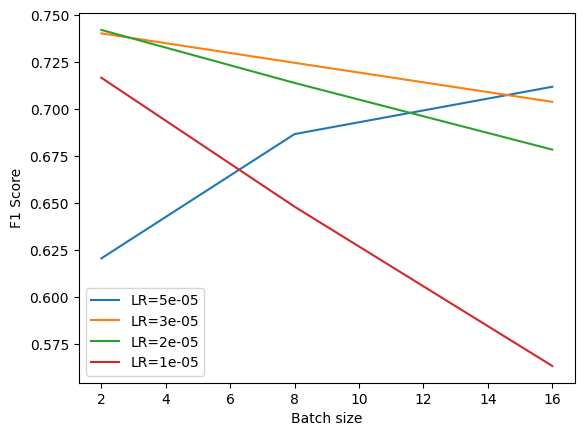

In [ ]:
# Extract unique learning rates from the DataFrame
learning_rates = hyperparam_subset30_xlnetbase['learning_rate'].unique()

# Plot the results
for lr in learning_rates:
    temp_df = hyperparam_subset30_xlnetbase[hyperparam_subset30_xlnetbase['learning_rate'] == lr]

    # Sort temp_df by 'train_batch_size' before plotting
    temp_df = temp_df.sort_values(by='train_batch_size')

    plt.plot(temp_df['train_batch_size'], temp_df['f1_score'], label=f'LR={lr}')

plt.xlabel('Batch size')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

In [ ]:
hyperparam_subset30_xlnetbase

,learning_rate,train_batch_size,f1_score
0,0.00005,2.0,0.620602
1,0.00005,8.0,0.686754
2,0.00005,16.0,0.711928
3,0.00003,2.0,0.740363
4,0.00003,8.0,0.724686
5,0.00003,16.0,0.703916
6,0.00002,2.0,0.742185
7,0.00002,8.0,0.713974
8,0.00002,16.0,0.678497
9,0.00001,2.0,0.716748


## XLnet-large-cased

In [ ]:
# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained("xlnet-large-cased")

# Preprocessing function
def preprocess_data(examples):
    text = examples["text"]
    encoding = tokenizer(text, padding="max_length", truncation=True, max_length=128)

    labels_batch = examples["labels"]
    labels_matrix = np.zeros((len(text), len(labels)))

    for i, label_list in enumerate(labels_batch):
        for label in label_list:
            idx = label2id[label]
            labels_matrix[i, idx] = 1

    encoding["labels"] = labels_matrix.tolist()

    return encoding

# Define metrics
def multi_label_metrics(predictions, labels, threshold=0.5):
    sigmoid = torch.nn.Sigmoid()
    probs = sigmoid(torch.Tensor(predictions))
    y_pred = np.zeros(probs.shape)
    y_pred[np.where(probs >= threshold)] = 1
    y_true = labels
    f1_micro_average = f1_score(y_true=y_true, y_pred=y_pred, average='micro')
    roc_auc = roc_auc_score(y_true, y_pred, average='micro')
    accuracy = accuracy_score(y_true, y_pred)
    metrics = {'f1': f1_micro_average,
               'roc_auc': roc_auc,
               'accuracy': accuracy}
    return metrics

def compute_metrics(p: EvalPrediction):
    preds = p.predictions[0] if isinstance(p.predictions, tuple) else p.predictions
    result = multi_label_metrics(predictions=preds, labels=p.label_ids)
    return result

# Function to train and evaluate the model for a given dataset
def train_and_evaluate_model(dataset, dataset_key, lr, batch_size):
    print(f"Training with {dataset_key} data, lr {lr}, batch_size {batch_size}...")

    # Apply preprocessing
    encoded_dataset = dataset.map(preprocess_data, batched=True, remove_columns=['text', 'labels'])

    # Set format to PyTorch tensors
    encoded_dataset.set_format("torch")

    # Define the model
    model = AutoModelForSequenceClassification.from_pretrained("xlnet-large-cased",
                                                               problem_type="multi_label_classification",
                                                               num_labels=len(labels),
                                                               id2label=id2label,
                                                               label2id=label2id)

    # Training arguments
    training_args = TrainingArguments(
        output_dir=f"xlnet-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=10,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
    )

    # Define the trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=encoded_dataset["train"],
        eval_dataset=encoded_dataset["validation"],
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )

    # Start training
    trainer.train()

    # Evaluation
    result = trainer.evaluate()
    print(f"Results with {dataset_key}, lr={lr} and batch_size={batch_size}: {result}")
    return result

##1%

In [ ]:
# Create a DataFrame to store the results
hyperparam_subset01_xlnetlarge = pd.DataFrame(columns=['learning_rate', 'train_batch_size', 'f1_score'])

In [ ]:
# Create a DataFrame to store the results
hyperparam_subset01_xlnetlarge = pd.read_csv('/content/gdrive/My Drive/MSc Project/hyperparam_subset01_xlnetlarge.csv')

In [ ]:

# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [5e-6],
    'train_batch_size': [2, 4, 8],
}

# Select only the "original" dataset
dataset_key = "original_subset01"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        hyperparam_subset01_xlnetlarge = hyperparam_subset01_xlnetlarge.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)
        # Save the DataFrame to the CSV file
        hyperparam_subset01_xlnetlarge.to_csv('/content/gdrive/My Drive/MSc Project/hyperparam_subset01_xlnetlarge.csv', index=False)

        # Remove the folder after processing
        folder_path = f"/content/xlnet-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}"
        !rm -r $folder_path

Training with original_subset01 data, lr 5e-06, batch_size 2...


Map:   0%|          | 0/88 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-large-cased and are newly initialized: ['sequence_summary.summary.weight', 'sequence_summary.summary.bias', 'logits_proj.bias', 'logits_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
You're using a XLNetTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.524657,0.150516,0.581959,0.000000
2,No log,0.397670,0.178957,0.566503,0.024898
3,No log,0.277866,0.003524,0.500616,0.000000
4,No log,0.233735,0.000357,0.500089,0.000315
5,No log,0.203815,0.000000,0.500000,0.000000
6,No log,0.190215,0.000000,0.500000,0.000000
7,No log,0.185779,0.000000,0.500000,0.000000
8,No log,0.182732,0.000000,0.500000,0.000000
9,No log,0.181019,0.000000,0.500000,0.000000
10,No log,0.181326,0.000000,0.500000,0.000000


...

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-large-cased and are newly initialized: ['sequence_summary.summary.weight', 'sequence_summary.summary.bias', 'logits_proj.bias', 'logits_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.641911,0.090797,0.509815,0.000000
2,No log,0.581773,0.075954,0.491756,0.000000
3,No log,0.537467,0.069519,0.492656,0.001261
4,No log,0.504875,0.059735,0.490092,0.008824
5,No log,0.465532,0.069152,0.505664,0.008509
6,No log,0.442908,0.070142,0.509323,0.008824
7,No log,0.417200,0.062161,0.509295,0.006934
8,No log,0.404886,0.048038,0.504963,0.005043
9,No log,0.397867,0.046034,0.505097,0.004727
10,No log,0.394872,0.043757,0.504700,0.003782


Results with original_subset01, lr=5e-06 and batch_size=8: {'eval_loss': 0.64191073179245, 'eval_f1': 0.09079728126011435, 'eval_roc_auc': 0.5098145773644005, 'eval_accuracy': 0.0, 'eval_runtime': 34.4684, 'eval_samples_per_second': 92.055, 'eval_steps_per_second': 11.518, 'epoch': 10.0}


<ipython-input-14-4d8bb0f8129f>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_subset01_xlnetlarge = hyperparam_subset01_xlnetlarge.append({


In [ ]:
# Print out the best hyperparameters
best_hyperparams = hyperparam_subset01_xlnetlarge.loc[hyperparam_subset01_xlnetlarge['f1_score'].idxmax()]
print(f"Best hyperparameters for xlnet-large model:\n{best_hyperparams}")

Best hyperparameters for xlnet-large model:
learning_rate       0.000005
train_batch_size    2.000000
f1_score            0.178957
Name: 11, dtype: float64


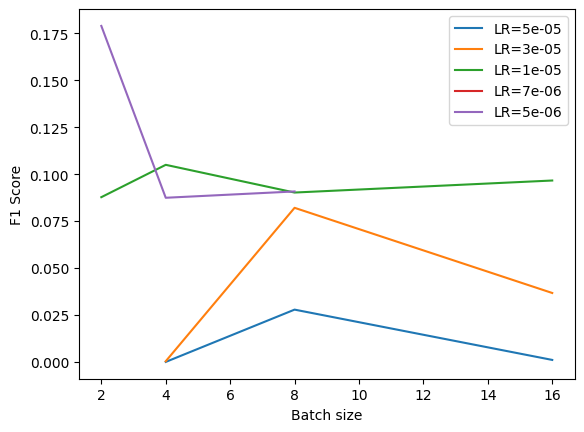

In [ ]:
# Extract unique learning rates from the DataFrame
learning_rates = hyperparam_subset01_xlnetlarge['learning_rate'].unique()

# Plot the results
for lr in learning_rates:
    temp_df = hyperparam_subset01_xlnetlarge[hyperparam_subset01_xlnetlarge['learning_rate'] == lr]

    # Sort temp_df by 'train_batch_size' before plotting
    temp_df = temp_df.sort_values(by='train_batch_size')

    plt.plot(temp_df['train_batch_size'], temp_df['f1_score'], label=f'LR={lr}')

plt.xlabel('Batch size')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

In [ ]:
hyperparam_subset01_xlnetlarge

,learning_rate,train_batch_size,f1_score
0,0.000050,4.0,0.000000
1,0.000050,8.0,0.027856
2,0.000050,16.0,0.001065
3,0.000030,4.0,0.000357
4,0.000030,8.0,0.082080
5,0.000030,16.0,0.036718
6,0.000010,4.0,0.104976
7,0.000010,8.0,0.090214
8,0.000010,16.0,0.096620
9,0.000010,2.0,0.087745


##5%

In [ ]:
# Create a DataFrame to store the results
hyperparam_subset05_xlnetlarge = pd.DataFrame(columns=['learning_rate', 'train_batch_size', 'f1_score'])

In [ ]:
# Create a DataFrame to store the results
hyperparam_subset05_xlnetlarge = pd.read_csv('/content/gdrive/My Drive/MSc Project/hyperparam_subset05_xlnetlarge.csv')

In [ ]:

# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [2e-5],
    'train_batch_size': [8, 16],
}

# Select only the "original" dataset
dataset_key = "original_subset05"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        hyperparam_subset05_xlnetlarge = hyperparam_subset05_xlnetlarge.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)
        # Save the DataFrame to the CSV file
        hyperparam_subset05_xlnetlarge.to_csv('/content/gdrive/My Drive/MSc Project/hyperparam_subset05_xlnetlarge.csv', index=False)

        # Remove the folder after processing
        folder_path = f"/content/xlnet-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}"
        !rm -r $folder_path

Training with original_subset05 data, lr 2e-05, batch_size 8...


Map:   0%|          | 0/380 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-large-cased and are newly initialized: ['sequence_summary.summary.weight', 'sequence_summary.summary.bias', 'logits_proj.bias', 'logits_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.179014,0.000000,0.500000,0.000000
2,No log,0.159172,0.000000,0.500000,0.000000
3,No log,0.155169,0.000000,0.500000,0.000000
4,No log,0.153284,0.000000,0.500000,0.000000
5,No log,0.150346,0.000000,0.500000,0.000000
6,No log,0.146225,0.000713,0.500178,0.000000
7,No log,0.140928,0.039765,0.509967,0.005673
8,No log,0.137039,0.042054,0.510541,0.005358
9,No log,0.134991,0.086928,0.522619,0.017964
10,No log,0.135473,0.157583,0.544163,0.033722


...

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-large-cased and are newly initialized: ['sequence_summary.summary.weight', 'sequence_summary.summary.bias', 'logits_proj.bias', 'logits_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.264615,0.000000,0.500000,0.000000
2,No log,0.171327,0.000000,0.500000,0.000000
3,No log,0.160851,0.000000,0.500000,0.000000
4,No log,0.157317,0.000000,0.500000,0.000000
5,No log,0.154931,0.000000,0.500000,0.000000
6,No log,0.150982,0.001425,0.500338,0.000000
7,No log,0.152241,0.000000,0.500000,0.000000
8,No log,0.147438,0.012685,0.503054,0.000315
9,No log,0.145286,0.030214,0.507456,0.002836
10,No log,0.145374,0.015490,0.503782,0.000000


Results with original_subset05, lr=2e-05 and batch_size=16: {'eval_loss': 0.14528609812259674, 'eval_f1': 0.030213578746310123, 'eval_roc_auc': 0.5074557374875647, 'eval_accuracy': 0.0028364323983611725, 'eval_runtime': 33.3762, 'eval_samples_per_second': 95.068, 'eval_steps_per_second': 5.962, 'epoch': 10.0}


<ipython-input-34-97f310ee2a6a>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_subset05_xlnetlarge = hyperparam_subset05_xlnetlarge.append({


In [ ]:
# Print out the best hyperparameters
best_hyperparams = hyperparam_subset05_xlnetlarge.loc[hyperparam_subset05_xlnetlarge['f1_score'].idxmax()]
print(f"Best hyperparameters for xlnet-large model:\n{best_hyperparams}")

Best hyperparameters for xlnet-large model:
learning_rate       0.000020
train_batch_size    4.000000
f1_score            0.568894
Name: 10, dtype: float64


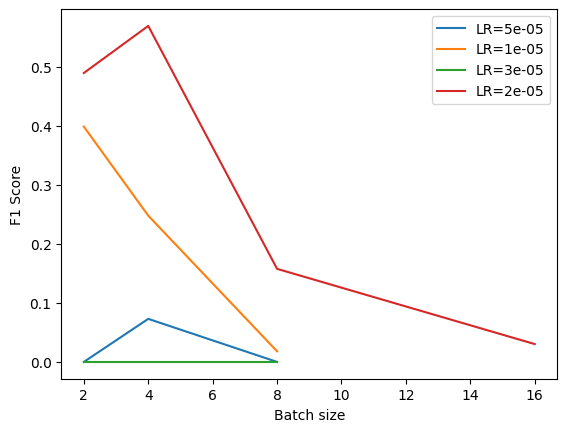

In [ ]:
# Extract unique learning rates from the DataFrame
learning_rates = hyperparam_subset05_xlnetlarge['learning_rate'].unique()

# Plot the results
for lr in learning_rates:
    temp_df = hyperparam_subset05_xlnetlarge[hyperparam_subset05_xlnetlarge['learning_rate'] == lr]

    # Sort temp_df by 'train_batch_size' before plotting
    temp_df = temp_df.sort_values(by='train_batch_size')

    plt.plot(temp_df['train_batch_size'], temp_df['f1_score'], label=f'LR={lr}')

plt.xlabel('Batch size')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

In [ ]:
hyperparam_subset05_xlnetlarge

,learning_rate,train_batch_size,f1_score
0,0.00005,2.0,0.000000
1,0.00005,4.0,0.072910
2,0.00005,8.0,0.000000
3,0.00001,2.0,0.398411
4,0.00001,4.0,0.247662
5,0.00001,8.0,0.017977
6,0.00003,2.0,0.000000
7,0.00003,4.0,0.000000
8,0.00003,8.0,0.000000
9,0.00002,2.0,0.489188


##10%

In [ ]:
# Create a DataFrame to store the results
hyperparam_subset10_xlnetlarge = pd.DataFrame(columns=['learning_rate', 'train_batch_size', 'f1_score'])

In [ ]:
# Create a DataFrame to store the results
hyperparam_subset10_xlnetlarge = pd.read_csv('/content/gdrive/My Drive/MSc Project/hyperparam_subset10_xlnetlarge.csv')

In [ ]:

# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [1e-5],
    'train_batch_size': [2, 8],
}

# Select only the "original" dataset
dataset_key = "original_subset10"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        hyperparam_subset10_xlnetlarge = hyperparam_subset10_xlnetlarge.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)
        # Save the DataFrame to the CSV file
        hyperparam_subset10_xlnetlarge.to_csv('/content/gdrive/My Drive/MSc Project/hyperparam_subset10_xlnetlarge.csv', index=False)

        # Remove the folder after processing
        folder_path = f"/content/xlnet-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}"
        !rm -r $folder_path

Training with original_subset10 data, lr 1e-05, batch_size 2...


Map:   0%|          | 0/750 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-large-cased and are newly initialized: ['sequence_summary.summary.weight', 'logits_proj.weight', 'logits_proj.bias', 'sequence_summary.summary.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.155934,0.000000,0.500000,0.000000
2,0.214100,0.141316,0.074497,0.519193,0.017649
3,0.144200,0.129797,0.257914,0.580243,0.072487
4,0.130400,0.119587,0.409069,0.649276,0.166719
5,0.130400,0.112380,0.487973,0.689970,0.208320
6,0.112600,0.105598,0.514856,0.696152,0.234794
7,0.097900,0.100690,0.562784,0.722412,0.296880
8,0.086000,0.097254,0.580243,0.732468,0.309171
9,0.086000,0.095995,0.590377,0.738820,0.315474
10,0.076600,0.095212,0.599033,0.744375,0.324614


...

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-large-cased and are newly initialized: ['sequence_summary.summary.weight', 'logits_proj.weight', 'logits_proj.bias', 'sequence_summary.summary.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.175718,0.000000,0.500000,0.000000
2,No log,0.157547,0.000000,0.500000,0.000000
3,No log,0.151753,0.000000,0.500000,0.000000
4,No log,0.146488,0.000000,0.500000,0.000000
5,No log,0.142626,0.007804,0.501916,0.000630
6,0.197800,0.135449,0.098903,0.526019,0.028679
7,0.197800,0.132902,0.107271,0.528428,0.029310
8,0.197800,0.130933,0.140558,0.538283,0.033722
9,0.197800,0.128297,0.167389,0.546793,0.046013
10,0.197800,0.127915,0.197418,0.556459,0.047589


Results with original_subset10, lr=1e-05 and batch_size=8: {'eval_loss': 0.1279149204492569, 'eval_f1': 0.1974183750949127, 'eval_roc_auc': 0.5564591735394152, 'eval_accuracy': 0.047589032461393004, 'eval_runtime': 33.492, 'eval_samples_per_second': 94.739, 'eval_steps_per_second': 11.854, 'epoch': 10.0}


<ipython-input-18-b085d30a8c77>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_subset10_xlnetlarge = hyperparam_subset10_xlnetlarge.append({


In [ ]:
# Print out the best hyperparameters
best_hyperparams = hyperparam_subset10_xlnetlarge.loc[hyperparam_subset10_xlnetlarge['f1_score'].idxmax()]
print(f"Best hyperparameters for xlnet-large model:\n{best_hyperparams}")

Best hyperparameters for xlnet-large model:
learning_rate       0.000010
train_batch_size    2.000000
f1_score            0.599033
Name: 6, dtype: float64


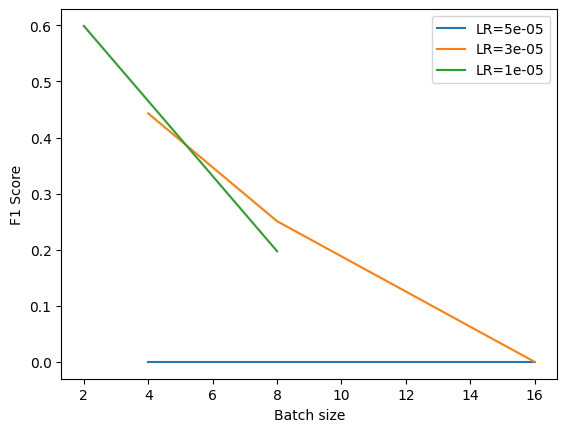

In [ ]:
# Extract unique learning rates from the DataFrame
learning_rates = hyperparam_subset10_xlnetlarge['learning_rate'].unique()

# Plot the results
for lr in learning_rates:
    temp_df = hyperparam_subset10_xlnetlarge[hyperparam_subset10_xlnetlarge['learning_rate'] == lr]

    # Sort temp_df by 'train_batch_size' before plotting
    temp_df = temp_df.sort_values(by='train_batch_size')

    plt.plot(temp_df['train_batch_size'], temp_df['f1_score'], label=f'LR={lr}')

plt.xlabel('Batch size')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

In [ ]:
hyperparam_subset10_xlnetlarge

,learning_rate,train_batch_size,f1_score
0,0.00005,4.0,0.000000
1,0.00005,8.0,0.000000
2,0.00005,16.0,0.000000
3,0.00003,4.0,0.443047
4,0.00003,8.0,0.250856
5,0.00003,16.0,0.000000
6,0.00001,2.0,0.599033
7,0.00001,8.0,0.197418


##20%

In [ ]:
# Create a DataFrame to store the results
hyperparam_subset20_xlnetlarge = pd.DataFrame(columns=['learning_rate', 'train_batch_size', 'f1_score'])

In [ ]:
# Create a DataFrame to store the results
hyperparam_subset20_xlnetlarge = pd.read_csv('/content/gdrive/My Drive/MSc Project/hyperparam_subset20_xlnetlarge.csv')

In [ ]:
# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [3e-5],
    'train_batch_size': [2],
}

# Select only the "original" dataset
dataset_key = "original_subset20"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        hyperparam_subset20_xlnetlarge = hyperparam_subset20_xlnetlarge.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)
        # Save the DataFrame to the CSV file
        hyperparam_subset20_xlnetlarge.to_csv('/content/gdrive/My Drive/MSc Project/hyperparam_subset20_xlnetlarge.csv', index=False)

        # Remove the folder after processing
        folder_path = f"/content/xlnet-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}"
        !rm -r $folder_path

Training with original_subset20 data, lr 3e-05, batch_size 2...


Map:   0%|          | 0/1517 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-large-cased and are newly initialized: ['sequence_summary.summary.weight', 'logits_proj.weight', 'logits_proj.bias', 'sequence_summary.summary.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,0.182600,0.153614,0.000000,0.500000,0.000000
2,0.156400,0.153101,0.000000,0.500000,0.000000
3,0.152500,0.152902,0.000000,0.500000,0.000000
4,0.151700,0.154034,0.000000,0.500000,0.000000
5,0.151200,0.153747,0.000000,0.500000,0.000000
6,0.154100,0.153610,0.000000,0.500000,0.000000
7,0.155200,0.153697,0.000000,0.500000,0.000000
8,0.148400,0.154135,0.000000,0.500000,0.000000
9,0.149500,0.155059,0.000000,0.500000,0.000000
10,0.148900,0.155295,0.000000,0.500000,0.000000


Results with original_subset20, lr=3e-05 and batch_size=2: {'eval_loss': 0.1536138504743576, 'eval_f1': 0.0, 'eval_roc_auc': 0.5, 'eval_accuracy': 0.0, 'eval_runtime': 63.5477, 'eval_samples_per_second': 49.931, 'eval_steps_per_second': 24.973, 'epoch': 10.0}


<ipython-input-28-306372bf8ad5>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_subset20_xlnetlarge = hyperparam_subset20_xlnetlarge.append({


In [ ]:
# Print out the best hyperparameters
best_hyperparams = hyperparam_subset20_xlnetlarge.loc[hyperparam_subset20_xlnetlarge['f1_score'].idxmax()]
print(f"Best hyperparameters for xlnet-large model:\n{best_hyperparams}")

Best hyperparameters for xlnet-large model:
learning_rate       0.000050
train_batch_size    8.000000
f1_score            0.684753
Name: 1, dtype: float64


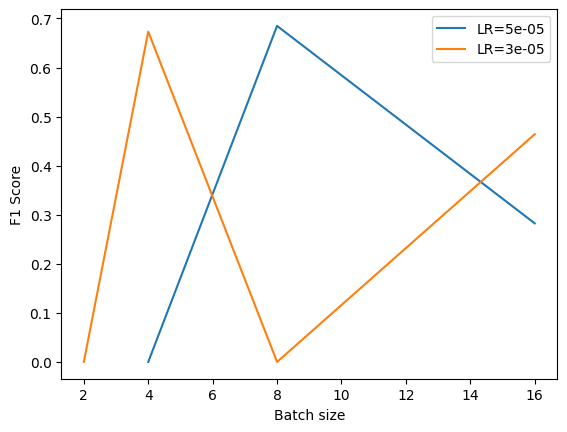

In [ ]:
# Extract unique learning rates from the DataFrame
learning_rates = hyperparam_subset20_xlnetlarge['learning_rate'].unique()

# Plot the results
for lr in learning_rates:
    temp_df = hyperparam_subset20_xlnetlarge[hyperparam_subset20_xlnetlarge['learning_rate'] == lr]

    # Sort temp_df by 'train_batch_size' before plotting
    temp_df = temp_df.sort_values(by='train_batch_size')

    plt.plot(temp_df['train_batch_size'], temp_df['f1_score'], label=f'LR={lr}')

plt.xlabel('Batch size')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

In [ ]:
hyperparam_subset20_xlnetlarge

,learning_rate,train_batch_size,f1_score
0,0.00005,4.0,0.000000
1,0.00005,8.0,0.684753
2,0.00005,16.0,0.282419
3,0.00003,4.0,0.673091
4,0.00003,8.0,0.000000
5,0.00003,16.0,0.464040
6,0.00003,2.0,0.000000


##30%

In [ ]:
# Create a DataFrame to store the results
hyperparam_subset30_xlnetlarge = pd.DataFrame(columns=['learning_rate', 'train_batch_size', 'f1_score'])

In [ ]:
# Create a DataFrame to store the results
hyperparam_subset30_xlnetlarge = pd.read_csv('/content/gdrive/My Drive/MSc Project/hyperparam_subset30_xlnetlarge.csv')

In [ ]:
# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [3e-5],
    'train_batch_size': [4, 8, 16],
}

# Select only the "original" dataset
dataset_key = "original_subset30"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        hyperparam_subset30_xlnetlarge = hyperparam_subset30_xlnetlarge.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)
        # Save the DataFrame to the CSV file
        hyperparam_subset30_xlnetlarge.to_csv('/content/gdrive/My Drive/MSc Project/hyperparam_subset30_xlnetlarge.csv', index=False)

        # Remove the folder after processing
        folder_path = f"/content/xlnet-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}"
        !rm -r $folder_path

Training with original_subset30 data, lr 3e-05, batch_size 4...


Map:   0%|          | 0/2247 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-large-cased and are newly initialized: ['sequence_summary.summary.weight', 'logits_proj.bias', 'sequence_summary.summary.bias', 'logits_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
You're using a XLNetTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,0.163800,0.130672,0.171583,0.547400,0.035298
2,0.130400,0.118886,0.356936,0.621958,0.137409
3,0.116000,0.106554,0.525642,0.701323,0.271667
4,0.104200,0.097671,0.585979,0.740532,0.314529
5,0.091700,0.089224,0.634467,0.763258,0.356130
6,0.079400,0.082742,0.682562,0.800530,0.432083
7,0.066700,0.076982,0.712363,0.823325,0.450362
8,0.056500,0.074136,0.721567,0.825795,0.463914
9,0.040700,0.073970,0.728993,0.835286,0.478412
10,0.036500,0.072483,0.739470,0.844997,0.482824


...

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-large-cased and are newly initialized: ['sequence_summary.summary.weight', 'logits_proj.bias', 'sequence_summary.summary.bias', 'logits_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.146936,0.000357,0.500089,0.000000
2,No log,0.126576,0.223454,0.565040,0.044753
3,No log,0.122087,0.384843,0.635084,0.159786
4,0.149000,0.115123,0.413366,0.647464,0.151276
5,0.149000,0.105042,0.526406,0.712522,0.243933
6,0.149000,0.099069,0.594103,0.748248,0.317996
7,0.149000,0.090523,0.643084,0.775762,0.369051
8,0.095300,0.086090,0.673206,0.795242,0.404349
9,0.095300,0.083642,0.678903,0.795869,0.416325
10,0.095300,0.083276,0.685697,0.803795,0.422944


Results with original_subset30, lr=3e-05 and batch_size=16: {'eval_loss': 0.08327572047710419, 'eval_f1': 0.6856972940826642, 'eval_roc_auc': 0.8037951467037862, 'eval_accuracy': 0.42294358651118813, 'eval_runtime': 32.5584, 'eval_samples_per_second': 97.456, 'eval_steps_per_second': 6.112, 'epoch': 10.0}


<ipython-input-17-ff6fba52620b>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_subset30_xlnetlarge = hyperparam_subset30_xlnetlarge.append({


In [ ]:
# Print out the best hyperparameters
best_hyperparams = hyperparam_subset30_xlnetlarge.loc[hyperparam_subset30_xlnetlarge['f1_score'].idxmax()]
print(f"Best hyperparameters for xlnet-large model:\n{best_hyperparams}")

Best hyperparameters for xlnet-large model:
learning_rate       0.00003
train_batch_size    4.00000
f1_score            0.73947
Name: 3, dtype: float64


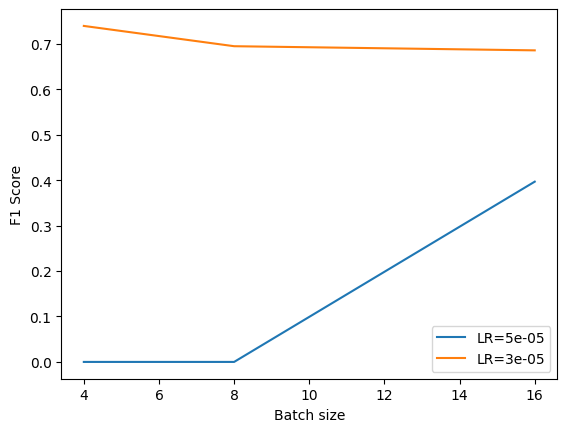

In [ ]:
# Extract unique learning rates from the DataFrame
learning_rates = hyperparam_subset30_xlnetlarge['learning_rate'].unique()

# Plot the results
for lr in learning_rates:
    temp_df = hyperparam_subset30_xlnetlarge[hyperparam_subset30_xlnetlarge['learning_rate'] == lr]

    # Sort temp_df by 'train_batch_size' before plotting
    temp_df = temp_df.sort_values(by='train_batch_size')

    plt.plot(temp_df['train_batch_size'], temp_df['f1_score'], label=f'LR={lr}')

plt.xlabel('Batch size')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

In [ ]:
hyperparam_subset30_xlnetlarge

,learning_rate,train_batch_size,f1_score
0,0.00005,4.0,0.000000
1,0.00005,8.0,0.000000
2,0.00005,16.0,0.396721
3,0.00003,4.0,0.739470
4,0.00003,8.0,0.694818
5,0.00003,16.0,0.685697
